# ORT: Kwantummechanische Verbinding

**Hoofdstuk 13 | §13.1–13.8 | Formules 104–113**

Dit notebook verkent de correspondentie tussen de Zijn-vector van de ORT
en de fundamentele grootheden uit de kwantummechanica.

> **Opmerking**: dit zijn *correspondenties*, geen afleiding van QM uit de ORT.
> De ORT laat zien dat haar structuur op natuurlijke wijze de grootheden bevat
> die in de kwantummechanica als conjugaat-paren optreden.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent / 'shared'))
from ort_core import (C, ORT,
                            H_PLANCK, HBAR, M_ELECTRON, M_PROTON)
from ort_plots import (zijn_qm_diagram, de_broglie_plot,
                             zijn_vector_diagram)
import numpy as np
import math

---
## §13.1 — De Zijn-vector als brug

De Zijn-vector (formules 16–17) heeft twee componenten:

$$S_{ruimte} = p = m_0 c \tan\theta \quad (104)$$
$$S_{tijd} = m_0 c \quad (105)$$

De ruimtecomponent is de impuls $p$; de tijdcomponent is de rustmassa maal de lichtsnelheid.
Dit zijn precies de grootheden die in de kwantummechanica als **conjugaat-paren** optreden:

- $x \leftrightarrow p = S_{ruimte}$ (ruimte-impuls)
- $t \leftrightarrow E = S_{tijd} \cdot c = m_0 c^2$ (tijd-energie)

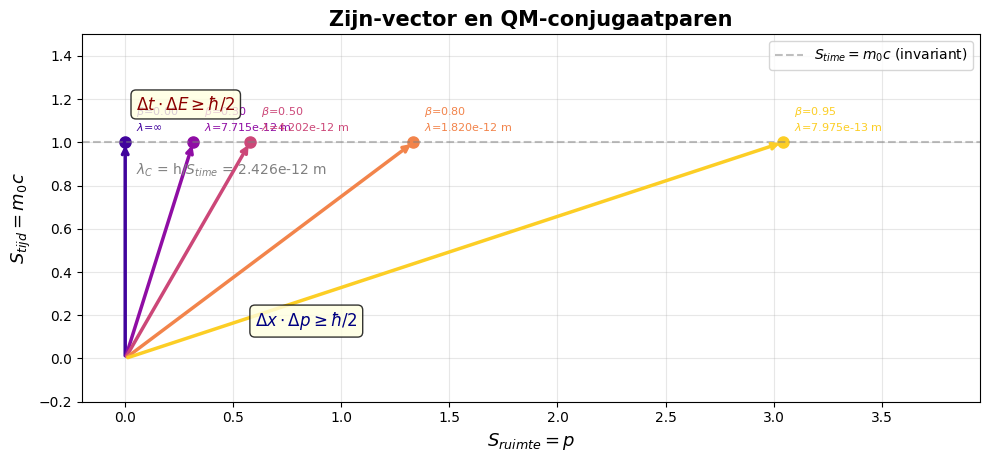

In [2]:
# Zijn-vector met QM-correspondentie
zijn_qm_diagram(m0=M_ELECTRON, lang='nl')
pass

In [3]:
# Numerieke verificatie: Zijn-componenten voor een elektron
print("=== Zijn-vector componenten (elektron) ===")
print(f"Rustmassa m₀ = {M_ELECTRON:.4e} kg")
print(f"S_tijd = m₀c = {M_ELECTRON * C:.4e} kg·m/s")
print()

for beta in [0.0, 0.1, 0.5, 0.9, 0.99]:
    stv = ORT.from_beta(beta)
    p = stv.momentum(M_ELECTRON)
    E = stv.total_energy(M_ELECTRON)
    theta = stv.theta_degrees
    print(f"β={beta:.2f}  θ={theta:6.2f}°  S_ruimte(=p)={p:.4e}  E=S·c={E:.4e} J")

=== Zijn-vector componenten (elektron) ===
Rustmassa m₀ = 9.1094e-31 kg
S_tijd = m₀c = 2.7309e-22 kg·m/s

β=0.00  θ=  0.00°  S_ruimte(=p)=0.0000e+00  E=S·c=8.1871e-14 J
β=0.10  θ=  5.74°  S_ruimte(=p)=2.7447e-23  E=S·c=8.2284e-14 J
β=0.50  θ= 30.00°  S_ruimte(=p)=1.5767e-22  E=S·c=9.4537e-14 J
β=0.90  θ= 64.16°  S_ruimte(=p)=5.6387e-22  E=S·c=1.8783e-13 J
β=0.99  θ= 81.89°  S_ruimte(=p)=1.9165e-21  E=S·c=5.8037e-13 J


---
## §13.2 — Onzekerheidsrelaties

De Heisenberg-onzekerheidsrelaties verbinden precies de grootheden
die in de Zijn-vector voorkomen:

$$\Delta x \cdot \Delta p \geq \hbar/2 \quad (106)$$
$$\Delta t \cdot \Delta E \geq \hbar/2 \quad (107)$$

- Formule (106) koppelt positie $x$ aan impuls $p = S_{ruimte}$.
- Formule (107) koppelt tijd $t$ aan energie $E$, die via $E = |\vec{S}| \cdot c$ met de Zijn-vector samenhangt.

De onzekerheidsrelaties zijn dus de **kwantumgrenzen** op de nauwkeurigheid
waarmee de componenten van de Zijn-vector bepaald kunnen worden.

In [4]:
# Onzekerheidsrelaties: minimale onzekerheden
print("=== Onzekerheidsrelaties ===")
print(f"ℏ = {HBAR:.4e} J·s")
print(f"ℏ/2 = {HBAR/2:.4e} J·s")
print()

# Voorbeeld: elektron opgesloten in een atoom (Δx ≈ 1 Å)
delta_x = 1e-10  # 1 Ångström
delta_p_min = HBAR / (2 * delta_x)
print(f"Elektron in atoom (Δx ≈ {delta_x:.0e} m):")
print(f"  Minimale Δp ≥ {delta_p_min:.4e} kg·m/s")
print(f"  Ter vergelijking: S_ruimte(β=0.01) = {ORT.from_beta(0.01).momentum(M_ELECTRON):.4e} kg·m/s")
print()

# Tijd-energie: Δt voor een foton met E = m_e c²
E_rest = M_ELECTRON * C**2
delta_t_min = HBAR / (2 * E_rest)
print(f"Rustenergie elektron E₀ = {E_rest:.4e} J = {E_rest / 1.602e-19:.1f} eV")
print(f"  Minimale Δt ≥ {delta_t_min:.4e} s")

=== Onzekerheidsrelaties ===
ℏ = 1.0546e-34 J·s
ℏ/2 = 5.2729e-35 J·s

Elektron in atoom (Δx ≈ 1e-10 m):
  Minimale Δp ≥ 5.2729e-25 kg·m/s
  Ter vergelijking: S_ruimte(β=0.01) = 2.7311e-24 kg·m/s

Rustenergie elektron E₀ = 8.1871e-14 J = 511055.3 eV
  Minimale Δt ≥ 6.4404e-22 s


---
## §13.3 — De Broglie-golflengte

De Broglie (1924) koppelde een golflengte aan elke deeltjesimpuls:

$$\lambda = \frac{h}{p} = \frac{h}{S_{ruimte}} \quad (108)$$

In ORT-termen: de golfeigenschap van materie is direct gekoppeld aan de
**ruimtecomponent** van de Zijn-vector. Hoe groter $S_{ruimte}$ (meer impuls,
dus grotere hoek $\theta$), hoe korter de golflengte.

In [5]:
# De Broglie-golflengte voor een elektron bij diverse snelheden
print("=== De Broglie-golflengte (elektron) ===")
print(f"  h = {H_PLANCK:.4e} J·s")
print()

lambda_C = ORT.compton_wavelength(M_ELECTRON)
print(f"{'\u03b2':>6}  {'\u03b8':>8}  {'\u03bb_dB':>12}  {'\u03bb_dB/\u03bb_C':>10}")
for beta in [0.001, 0.01, 0.1, 0.5, 0.9, 0.99, 0.999]:
    stv = ORT.from_beta(beta)
    lam = stv.de_broglie_wavelength(M_ELECTRON)
    print(f"{beta:6.3f}  {stv.theta_degrees:8.3f}°  {lam:12.4e} m  {lam/lambda_C:10.2f}")

=== De Broglie-golflengte (elektron) ===
  h = 6.6261e-34 J·s

     β         θ          λ_dB    λ_dB/λ_C
 0.001     0.057°    2.4263e-09 m     1000.00
 0.010     0.573°    2.4262e-10 m       99.99
 0.100     5.739°    2.4141e-11 m        9.95
 0.500    30.000°    4.2025e-12 m        1.73
 0.900    64.158°    1.1751e-12 m        0.48
 0.990    81.890°    3.4573e-13 m        0.14
 0.999    87.437°    1.0859e-13 m        0.04


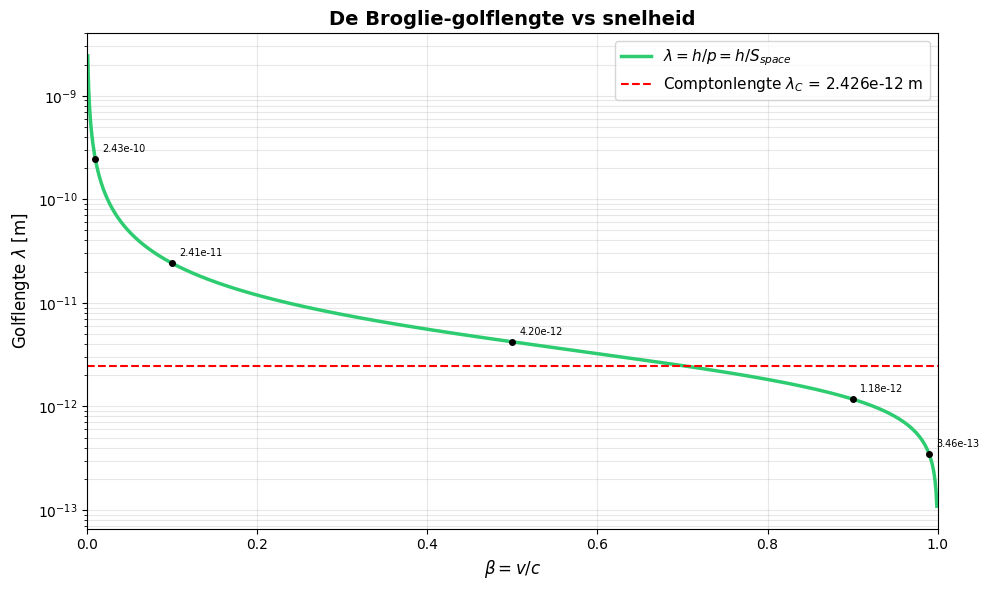

In [6]:
# De Broglie-golflengte vs snelheid
de_broglie_plot(m0=M_ELECTRON, lang='nl')
pass

---
## §13.4 — Planck-Einstein-relatie

De energie van een foton is gekoppeld aan zijn frequentie:

$$E = hf \quad (109)$$

Voor een deeltje in rust ($\theta = 0$, $E = m_0 c^2$) definieert dit
de **Compton-frequentie**:

$$f_0 = \frac{m_0 c^2}{h} \quad (110)$$

Dit is de "tikfrequentie" van het deeltje in rust — de frequentie die
hoort bij de tijdcomponent van de Zijn-vector.

In [7]:
# Compton-frequentie
print("=== Compton-frequentie (tikfrequentie in rust) ===")
print()

for name, m0 in [("Elektron", M_ELECTRON), ("Proton", M_PROTON)]:
    f0 = ORT.compton_frequency(m0)
    E0 = m0 * C**2
    print(f"{name}:")
    print(f"  m₀ = {m0:.4e} kg")
    print(f"  E₀ = m₀c² = {E0:.4e} J = {E0/1.602e-19:.0f} eV")
    print(f"  f₀ = m₀c²/h = {f0:.4e} Hz")
    print()

# Relativistische frequentie: f = f₀/cosθ
print("Relativistische frequentie elektron:")
for beta in [0.0, 0.5, 0.9, 0.99]:
    stv = ORT.from_beta(beta)
    f = stv.particle_frequency(M_ELECTRON)
    f0 = ORT.compton_frequency(M_ELECTRON)
    print(f"  β={beta:.2f}  θ={stv.theta_degrees:6.2f}°  f = {f:.4e} Hz  (f/f₀ = {f/f0:.4f} = 1/cosθ)")

=== Compton-frequentie (tikfrequentie in rust) ===

Elektron:
  m₀ = 9.1094e-31 kg
  E₀ = m₀c² = 8.1871e-14 J = 511055 eV
  f₀ = m₀c²/h = 1.2356e+20 Hz

Proton:
  m₀ = 1.6726e-27 kg
  E₀ = m₀c² = 1.5033e-10 J = 938375541 eV
  f₀ = m₀c²/h = 2.2687e+23 Hz

Relativistische frequentie elektron:
  β=0.00  θ=  0.00°  f = 1.2356e+20 Hz  (f/f₀ = 1.0000 = 1/cosθ)
  β=0.50  θ= 30.00°  f = 1.4267e+20 Hz  (f/f₀ = 1.1547 = 1/cosθ)
  β=0.90  θ= 64.16°  f = 2.8346e+20 Hz  (f/f₀ = 2.2942 = 1/cosθ)
  β=0.99  θ= 81.89°  f = 8.7589e+20 Hz  (f/f₀ = 7.0888 = 1/cosθ)


---
## §13.5 — Comptonlengte

De Comptonlengte is het ruimtelijke equivalent van de Compton-frequentie:

$$\lambda_C = \frac{h}{m_0 c} = \frac{h}{S_{tijd}} \quad (111)$$

Dit is de fundamentele lengteschaal waaronder kwantumveldeneffecten
belangrijk worden voor een deeltje met massa $m_0$.

De Comptonlengte is direct de verhouding van de Planck-constante tot de
**tijdcomponent** van de Zijn-vector.

In [8]:
# Comptonlengte
print("=== Comptonlengte λ_C = h/(m₀c) = h/S_tijd ===")
print()

for name, m0 in [("Elektron", M_ELECTRON), ("Proton", M_PROTON)]:
    lam_C = ORT.compton_wavelength(m0)
    S_tijd = m0 * C
    print(f"{name}:")
    print(f"  S_tijd = m₀c = {S_tijd:.4e} kg·m/s")
    print(f"  λ_C = h/S_tijd = {lam_C:.4e} m")
    print(f"  Verificatie: h/λ_C = {H_PLANCK/lam_C:.4e} = S_tijd ✓")
    print()

=== Comptonlengte λ_C = h/(m₀c) = h/S_tijd ===

Elektron:
  S_tijd = m₀c = 2.7309e-22 kg·m/s
  λ_C = h/S_tijd = 2.4263e-12 m
  Verificatie: h/λ_C = 2.7309e-22 = S_tijd ✓

Proton:
  S_tijd = m₀c = 5.0144e-19 kg·m/s
  λ_C = h/S_tijd = 1.3214e-15 m
  Verificatie: h/λ_C = 5.0144e-19 = S_tijd ✓



---
## §13.6 — Golffunctie en de Zijn-vector

De vlakke-golf-oplossing van de Schrödinger/Klein-Gordon-vergelijking is:

$$\psi \sim \exp\left[\frac{i(px - Et)}{\hbar}\right] \quad (112)$$

Beide exponenten bevatten Zijn-componenten:
- $px = S_{ruimte} \cdot x$
- $Et = |\vec{S}|c \cdot t$

De fase van de golffunctie wordt dus volledig bepaald door de Zijn-vector
en de ruimtetijd-coördinaten.

In [9]:
# Fase van de golffunctie: φ = (px - Et)/ℏ
print("=== Golffunctie-fase (elektron, β=0.5) ===")
beta = 0.5
stv = ORT.from_beta(beta)
p = stv.momentum(M_ELECTRON)
E = stv.total_energy(M_ELECTRON)
print(f"β = {beta}, θ = {stv.theta_degrees:.2f}°")
print(f"p = S_ruimte = {p:.4e} kg·m/s")
print(f"E = |S|·c    = {E:.4e} J")
print()

# Fase bij x = 1 Å, t = 1 fs
x = 1e-10  # 1 Ångström
t = 1e-15  # 1 femtoseconde
fase = (p * x - E * t) / HBAR
print(f"Bij x = {x:.0e} m, t = {t:.0e} s:")
print(f"  φ = (px - Et)/ℏ = {fase:.4f} rad")
print(f"  Dit correspondeert met {fase/(2*np.pi):.2f} volledige golflengtes")

=== Golffunctie-fase (elektron, β=0.5) ===
β = 0.5, θ = 30.00°
p = S_ruimte = 1.5767e-22 kg·m/s
E = |S|·c    = 9.4537e-14 J

Bij x = 1e-10 m, t = 1e-15 s:
  φ = (px - Et)/ℏ = -896295.4054 rad
  Dit correspondeert met -142649.84 volledige golflengtes


---
## §13.7 — Overzichtstabel ORT ↔ QM

| ORT-grootheid | Symbool | QM-grootheid | Relatie |
|---------------|---------|--------------|--------|
| Zijn-ruimte | $S_r = p$ | Impuls | $\lambda = h/p$ (de Broglie) |
| Zijn-tijd | $S_t = m_0 c$ | Rustmassa × c | $\lambda_C = h/S_t$ (Compton) |
| Zijn-grootte | $|\vec{S}| = E/c$ | Energie/c | $E = hf$ (Planck-Einstein) |
| Zijn-hoek | $\theta$ | Verhouding p/m₀c | $\tan\theta = \lambda_C/\lambda$ |

De hoek $\theta$ is de arctangens van de verhouding van de Comptonlengte
tot de de Broglie-golflengte:

$$\tan\theta = \frac{p}{m_0 c} = \frac{\lambda_C}{\lambda} \quad (113)$$

In [10]:
# Overzichtstabel: alle QM-grootheden voor een elektron
print("=== Overzicht ORT ↔ QM (elektron) ===")
print()

lam_C = ORT.compton_wavelength(M_ELECTRON)
f0 = ORT.compton_frequency(M_ELECTRON)
print(f"Comptonlengte  λ_C = h/S_tijd = {lam_C:.4e} m")
print(f"Comptonfreq.   f₀  = m₀c²/h  = {f0:.4e} Hz")
print()

print(f"{'\u03b2':>6}  {'\u03b8':>8}  {'\u03bb_dB':>12}  {'\u03bb_C/\u03bb_dB':>10}  {'tan \u03b8':>10}  {'match':>5}")
for beta in [0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 0.99]:
    stv = ORT.from_beta(beta)
    lam = stv.de_broglie_wavelength(M_ELECTRON)
    ratio = lam_C / lam
    tan_theta = math.tan(stv.theta)
    match = "✓" if abs(ratio - tan_theta) < 1e-10 else "✗"
    print(f"{beta:6.2f}  {stv.theta_degrees:8.3f}°  {lam:12.4e} m  {ratio:10.6f}  {tan_theta:10.6f}  {match}")

=== Overzicht ORT ↔ QM (elektron) ===

Comptonlengte  λ_C = h/S_tijd = 2.4263e-12 m
Comptonfreq.   f₀  = m₀c²/h  = 1.2356e+20 Hz

     β         θ          λ_dB    λ_C/λ_dB       tan θ  match
  0.01     0.573°    2.4262e-10 m    0.010001    0.010001  ✓
  0.10     5.739°    2.4141e-11 m    0.100504    0.100504  ✓
  0.30    17.458°    7.7152e-12 m    0.314485    0.314485  ✓
  0.50    30.000°    4.2025e-12 m    0.577350    0.577350  ✓
  0.70    44.427°    2.4753e-12 m    0.980196    0.980196  ✓
  0.90    64.158°    1.1751e-12 m    2.064742    2.064742  ✓
  0.99    81.890°    3.4573e-13 m    7.017924    7.017924  ✓


---
## §13.8 — Beperkingen

Deze correspondentie is een **observatie**, geen afleiding van de
kwantummechanica uit de ORT. Specifiek:

1. De onzekerheidsrelaties worden niet *afgeleid* — ze worden herkend als grenzen op de Zijn-componenten.
2. De waarde van $\hbar$ wordt niet verklaard — zij komt als externe constante binnen.
3. De ORT beschrijft geen kwantumtoestanden, superpositie, verstrengeling of meetprobleem.
4. De correspondentie werkt op het niveau van de speciale relativiteit; een uitbreiding naar QFT in gekromde ruimtetijd is niet uitgewerkt.

> **Samenvatting**: de Zijn-vector van de ORT bevat in zijn twee componenten
> ($p$ en $m_0 c$) precies de grootheden die in de QM als conjugaat-paren optreden.
> De de Broglie-golflengte, Comptonlengte en golffunctiefase worden alle
> uitgedrukt in termen van de Zijn-vector. Dit suggereert dat de ORT-structuur
> een natuurlijke brug vormt tussen relativiteit en kwantummechanica, maar het
> is (nog) geen volledige unificatie.

---
## Samenvatting

In dit notebook hebben we gezien dat:

- De **Zijn-vector** ($S_{ruimte} = p$, $S_{tijd} = m_0 c$) precies de conjugaat-paren van de QM bevat
- De **onzekerheidsrelaties** grenzen stellen aan de nauwkeurigheid van Zijn-componenten
- De **de Broglie-golflengte** $\lambda = h/S_{ruimte}$ de golfnatuur van materie direct koppelt aan de ruimtecomponent
- De **Comptonlengte** $\lambda_C = h/S_{tijd}$ de fundamentele lengteschaal is van de tijdcomponent
- De **golffunctiefase** volledig wordt bepaald door Zijn-componenten en ruimtetijd-coördinaten
- De **Zijn-hoek** $\theta$ direct de verhouding $\lambda_C/\lambda$ geeft

**Volgende stappen**: zie [notebook 02](02_zwaartekracht_basis.ipynb) voor de uitbreiding naar zwaartekracht,
of [notebook 01](01_speciale_relativiteit.ipynb) voor de fundamenten van de speciale relativiteit.